# Week 4

- Prior skal være på phi tilde og ikke phi 
- Skal være mellem -1 og 1
- Ar2 model istedet. 
- Højere orrdens markov processer. 

We use change of variable

$$
\phi = \frac{2e^{\tilde{\phi}}}{1 + e^{\tilde{\phi}}} - 1
$$

$$
\frac{d\phi}{d \tilde{\phi}} = (\frac{2e^{\tilde{\phi}}}{1 + e^{\tilde{\phi}}} )'

= 2e^{\tilde{\phi}} \cdot (1 + e^{\tilde{\phi}})^{-1}

= (2e^{\tilde{\phi}} )' \cdot (1 + e^{\tilde{\phi}})^{-1} + 2e^{\tilde{\phi}} \cdot ( (1 + e^{\tilde{\phi}})^{-1})'

$$

$$
2e^{\tilde{\phi}}  \cdot (1 + e^{\tilde{\phi}})^{-1} + 2e^{\tilde{\phi}} \cdot ( -1 (1 + e^{\tilde{\phi}})^{-2} \cdot e^{\tilde{\phi}} )
$$

$$
2e^{\tilde{\phi}}  \cdot (1 + e^{\tilde{\phi}})^{-1} -  2e^{2\tilde{\phi}} \cdot (1 + e^{\tilde{\phi}})^{-2} 
$$


$$
=
\frac{(1 + e^{\tilde{\phi}})2e^{\tilde{\phi}}}{  (1 + e^{\tilde{\phi}})^{-2} }-  \frac{2e^{2\tilde{\phi}}}{(1 + e^{\tilde{\phi}})^{-2} }
$$


$$
= \frac{2e^{\tilde{\phi}} + 2e^{2\tilde{\phi}} - 2e^{2\tilde{\phi}}}{(1 + e^{\tilde{\phi}})^{2}}
= \frac{2e^{\tilde{\phi}}}{(1 + e^{\tilde{\phi}})^{2}}
$$

## Config

In [3]:
import jax 
from src.data import load_model_and_data 
from src.optim.loss import negative_log_likelihood_v2
from src.config.modelnames import MODELTYPES 

jax.config.update("jax_enable_x64", True)  # Enable 64-bit precision for JAX 

PHI_SIGMA = 0.5


RUN_TO_LOAD = {
    "tag": "week_2",
    "run": 1
}




### Loading HMM Autoregressive models

In [2]:
import jax.numpy as jnp

#Models 
from src.models.v1.ar_hmm import ArHMM
from src.models.v2.ar_prior_hmm_constrained import ArHMMPriorConstrained
from src.models.v2.ar_hmm_constrained import ArHMMConstrained
from src.models.v2.ar_prior_hmm import ArHMMPhiPrior


params, y_old, _ = load_model_and_data(modelname=MODELTYPES.AR_HMM, tag=RUN_TO_LOAD["tag"], run=RUN_TO_LOAD["run"])
x = y_old[:-1]  # Previous observations as inputs
y = y_old[1:]   # Current observations as targets
X = jnp.stack([x,x,x,x], axis=1)  # Same lagged observations for each state, shape (T, num_states) 

# Inverse of phi = (2*exp(phi_tilde))/(1+exp(phi_tilde)) - 1  =>  phi_tilde = log((1+phi)/(1-phi))
# Clip phi to (-1, 1) since the constrained model enforces this range
phi_clipped = jnp.clip(params.phi, -0.999, 0.999)
phi_tilde = jnp.log((1 + phi_clipped) / (1 - phi_clipped))




model_free = ArHMM(transition_logits=params.transition_logits, mu=params.mu, log_sigma=jnp.log(params.sigma), phi=params.phi)
model_constrained = ArHMMConstrained(transition_logits=params.transition_logits, mu=params.mu, log_sigma=jnp.log(params.sigma), phi_tilde=phi_tilde) 
model_prior = ArHMMPhiPrior(transition_logits=params.transition_logits, mu=params.mu, log_sigma=jnp.log(params.sigma), phi=params.phi, phi_sigma=PHI_SIGMA)
model_prior_constrained = ArHMMPriorConstrained(transition_logits=params.transition_logits, mu=params.mu, log_sigma=jnp.log(params.sigma), phi_tilde=phi_tilde, phi_sigma=PHI_SIGMA)

models_list = [model_free, model_constrained, model_prior, model_prior_constrained] 


## Preforming Optimization

In [3]:
for model in models_list:
    nll = negative_log_likelihood_v2(model, y, X)
    print(f"Model: {model.__class__.__name__}, Negative Log-Likelihood: {nll}")
    if "prior" in model.__class__.__name__.lower():
        log_prior = model.log_prior()
        print(f"Model: {model.__class__.__name__}, Log Prior: {log_prior}")


Model: ArHMM, Negative Log-Likelihood: 9138.617933982428
Model: ArHMMConstrained, Negative Log-Likelihood: 9190.610337238886
Model: ArHMMPhiPrior, Negative Log-Likelihood: 9143.81365588073
Model: ArHMMPhiPrior, Log Prior: -5.1957218983004125
Model: ArHMMPriorConstrained, Negative Log-Likelihood: 9212.298667159195
Model: ArHMMPriorConstrained, Log Prior: -21.6883299203099


Preforming optimization

In [4]:
from src.optim.loss import negative_log_likelihood_v2
from src.optim.lbfgs import LFBGSOptimizer 
from src.data import save_model_and_data

opt_model_list = [] 
opt_models_names = []

for model in models_list:
    optimizer = LFBGSOptimizer(model=model, loss_fn=negative_log_likelihood_v2)
    optimized_model = optimizer.run(y, X)
    opt_model_list.append(optimized_model) 
    opt_models_names.append(optimized_model.__class__.__name__)
    print(f"Optimized model: {optimized_model.__class__.__name__}")
    print(f"Negative Log-Likelihood after optimization: {negative_log_likelihood_v2(optimized_model, y, X)}") 
    save_model_and_data(modelname = optimized_model.__class__.__name__, tag="week4", run=0, model=optimized_model, y=y, X=X)



Optimized model: ArHMM
Negative Log-Likelihood after optimization: 9126.977926224914
Optimized model: ArHMMConstrained
Negative Log-Likelihood after optimization: 9092.881973878655
Optimized model: ArHMMPhiPrior
Negative Log-Likelihood after optimization: 9062.57039186171
Optimized model: ArHMMPriorConstrained
Negative Log-Likelihood after optimization: 9118.445118407602


In [5]:
#printing phi vals 

for model in opt_model_list:
    print(f"Model: {model.__class__.__name__}")
    if (hasattr(model.emission, 'phi')):
        print(model.emission.phi)
    else: 
        phi = (2 * jnp.exp(model.emission.phi_tilde)) / (1 + jnp.exp(model.emission.phi_tilde)) - 1
        print(phi) 

Model: ArHMM
[1.00010152 1.03894708 0.74381229 0.64571989]
Model: ArHMMConstrained
[1.         1.         0.62802409 0.7458559 ]
Model: ArHMMPhiPrior
[1.00008661 1.04719034 0.61923057 0.73512919]
Model: ArHMMPriorConstrained
[0.99988356 0.99899256 0.62390931 0.74544576]


In [8]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
y_np = np.array(y_old)  # Convert JAX array to NumPy array 


model = ARIMA(y_np, order=(2, 0, 0)).fit()

print(f"Log-Likelihood of AR(2) model: {model.llf:.4f}") 
print(model.summary())  

Log-Likelihood of AR(2) model: -10207.1111
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1666
Model:                 ARIMA(2, 0, 0)   Log Likelihood              -10207.111
Date:                Tue, 17 Mar 2026   AIC                          20422.222
Time:                        11:03:04   BIC                          20443.895
Sample:                             0   HQIC                         20430.254
                               - 1666                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        805.6580     48.949     16.459      0.000     709.719     901.597
ar.L1          1.3033      0.015     84.654      0.000       1.273       1.334
ar.L2    

Model: ArHMM


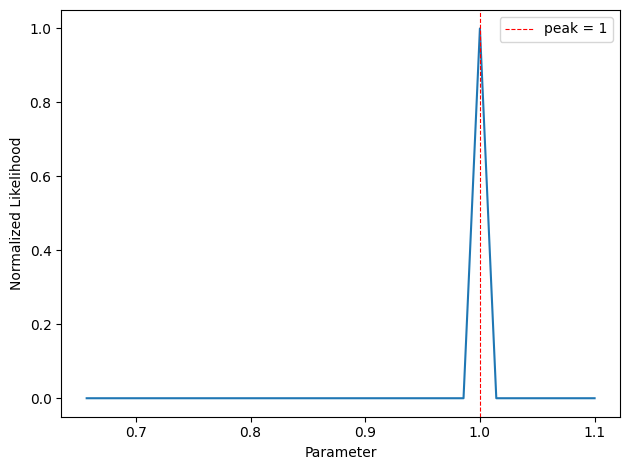

Model: ArHMMConstrained


In [ ]:
import equinox as eqx
import numpy as np
import matplotlib.pyplot as plt
from src.utils import plot_likelihood
from concurrent.futures import ThreadPoolExecutor

# phi[0] grid: constrained models only support (-1, 1), free models allow > 1
PHI_GRID_CONSTRAINED = np.linspace(0.50, 0.999, 50)
PHI_GRID_FREE        = np.linspace(0.4, 1.10,  50)
NUM_WORKERS = 8


def make_profile_loss(model, phi0):
    """Pin phi[0] to phi0, handling both phi and phi_tilde parameterisations."""
    if hasattr(model.emission, 'phi_tilde'):
        phi_tilde_0 = float(jnp.log((1 + phi0) / (1 - phi0)))
        def loss(m, y, X):
            pt = m.emission.phi_tilde.at[0].set(phi_tilde_0)
            m2 = eqx.tree_at(lambda z: z.emission.phi_tilde, m, pt)
            return negative_log_likelihood_v2(m2, y, X)
    else:
        def loss(m, y, X):
            p = m.emission.phi.at[0].set(phi0)
            m2 = eqx.tree_at(lambda z: z.emission.phi, m, p)
            return negative_log_likelihood_v2(m2, y, X)
    return loss


def profile_one_point(args):
    model, phi0, y, X = args
    loss_fn = make_profile_loss(model, phi0)
    opt = LFBGSOptimizer(model=model, loss_fn=loss_fn)
    opt_model = opt.run(y, X)
    return float(-loss_fn(opt_model, y, X)) 



for model in opt_model_list:
    print(f"Model: {model.__class__.__name__}")
    is_constrained = hasattr(model.emission, 'phi_tilde')

    phi_grid = PHI_GRID_CONSTRAINED if is_constrained else PHI_GRID_FREE                                                 

    task_args = [(model, float(phi0), y, X) for phi0 in phi_grid]                                                              

    with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:                                                              
        log_likes = np.array(list(executor.map(profile_one_point, task_args))) 


    plot_likelihood(phi_grid, log_likes) 


------------- OLD CODE -------------------

In [10]:
JANS_LIKELIHOOD = -9354.0 
print(f"Log-Likelihood of AR-HMM model: {-negative_log_likelihood(model, y, X):.4f}")
print(f"Jans log-likelihood: {JANS_LIKELIHOOD:.4f}")

Log-Likelihood of AR-HMM model: -9145.6768
Jans log-likelihood: -9354.0000


In [11]:
mu, sigma, transition_matrix = model.emission.mu, jnp.exp(model.emission.log_sigma), model.transition.transition_matrix
phi = model.emission.phi 
mu = jnp.concatenate([jnp.array([400.0]), mu])  # Add zero for the first state (AR(2) state)

for i, (m, s) in enumerate(zip(mu, sigma)):
    print(f"State {i}: mu={m:.4f}, sigma={s:.4f}, phi={phi[i]:.4f}")

State 0: mu=400.0000, sigma=0.4363, phi=1.0001
State 1: mu=535.6805, sigma=39.5384, phi=1.0379
State 2: mu=889.9311, sigma=187.6028, phi=0.7414
State 3: mu=1306.7014, sigma=39.9664, phi=0.6426


![Results for 4 states ArrHmm](images/jans_book/arr_hmm/params.png)

![Results for 4 states ArrHmm](images/jans_book/arr_hmm/tpm.png)

We now test that given Jans parameters, we will get the same likelihood

In [12]:
from src.models.v1.ar_hmm import ArHMM  
from src.optim.minimizer import Minimizer 

#JANS RESULTS 
mu = jnp.array([453, 730, 1590]) 
sigma = jnp.array([13, 42, 108, 72]) 
phi = jnp.array([0.97, 0.30, 0.62, 0.85 ]) 


Gamma = jnp.array([
    [8.2e-01, 0.0946, 0.0870, 9.3e-09],
    [1.8e-01, 0.6875, 0.1360, 5.5e-09],
    [9.6e-02, 0.2104, 0.4140, 2.8e-01],
    [2.3e-08, 0.0049, 0.1330, 8.6e-01],
])

stat_dist = jnp.array([[0.29, 0.21, 0.17, 0.34]])


## CONVERTING TO MODEL PARAMS 
num_states = 4
tGamma = jnp.zeros((num_states, num_states))
tGamma = tGamma.at[jnp.diag_indices(num_states)].set(0.0)
rows, cols = jnp.where(~jnp.eye(num_states, dtype=bool), size=num_states * (num_states - 1))
tGamma = tGamma.at[rows, cols].set(jnp.log(Gamma[rows, cols])) 

offdiag_mask = ~jnp.eye(num_states, dtype=bool)
tGamma_no_diag = tGamma[offdiag_mask].reshape(num_states, num_states - 1)


class ArHMMTest(ArHMM): 
    tpm : jnp.ndarray 
    def __init__(self, mu, log_sigma, phi, transition_logits, tpm):
    
        self.tpm = tpm
        super().__init__(mu=mu, log_sigma=log_sigma, phi=phi, transition_logits=transition_logits)


    def transition_matrix(self, xt = None): 
        return self.tpm 
    



arr_hmm_test = ArHMMTest(mu=mu, log_sigma=jnp.log(sigma), phi=phi, transition_logits=tGamma_no_diag, tpm=Gamma)

x =  y[:-1]  # Lagged observations for AR component 
X = jnp.stack([x,x,x,x], axis=1)  # Same lagged observations for each state, shape (T, num_states) 

print(f"Log-Likelihood of AR-HMM model with Jans parameters: {-negative_log_likelihood(arr_hmm_test, y[1:], X):.4f}")
print(f"Jans log-likelihood: {JANS_LIKELIHOOD:.4f}")





for i, (m_jan, m, s_jan, s, p_jan, p) in enumerate(zip(mu, arr_hmm_test.emission.mu, sigma, arr_hmm_test.emission.log_sigma, phi, arr_hmm_test.emission.phi)):
    
    print(f"State {i}:")
    print(f"  Jans mu: {m_jan:.4f}, Model mu: {m:.4f}")
    print(f"  Jans sigma: {s_jan:.4f}, Model sigma: {jnp.exp(s):.4f}")
    print(f"  Jans phi: {p_jan:.4f}, Model phi: {p:.4f}")
    print()


Gamma_from_model = arr_hmm_test.transition_matrix()

for i in range(num_states):
    print(f"State {i} transition probabilities:") 
    for j in range(num_states):
        print(f"  To state {j}: {Gamma_from_model[i, j]:.4f} (Jans: {Gamma[i, j]:.4f})")


print("Stationary distribution from model:")
print(arr_hmm_test.transition.u0())
print("Stationary distribution from Jans:")
print(stat_dist)

Log-Likelihood of AR-HMM model with Jans parameters: -9354.5125
Jans log-likelihood: -9354.0000
State 0:
  Jans mu: 453.0000, Model mu: 453.0000
  Jans sigma: 13.0000, Model sigma: 13.0000
  Jans phi: 0.9700, Model phi: 0.9700

State 1:
  Jans mu: 730.0000, Model mu: 730.0000
  Jans sigma: 42.0000, Model sigma: 42.0000
  Jans phi: 0.3000, Model phi: 0.3000

State 2:
  Jans mu: 1590.0000, Model mu: 1590.0000
  Jans sigma: 108.0000, Model sigma: 108.0000
  Jans phi: 0.6200, Model phi: 0.6200

State 0 transition probabilities:
  To state 0: 0.8200 (Jans: 0.8200)
  To state 1: 0.0946 (Jans: 0.0946)
  To state 2: 0.0870 (Jans: 0.0870)
  To state 3: 0.0000 (Jans: 0.0000)
State 1 transition probabilities:
  To state 0: 0.1800 (Jans: 0.1800)
  To state 1: 0.6875 (Jans: 0.6875)
  To state 2: 0.1360 (Jans: 0.1360)
  To state 3: 0.0000 (Jans: 0.0000)
State 2 transition probabilities:
  To state 0: 0.0960 (Jans: 0.0960)
  To state 1: 0.2104 (Jans: 0.2104)
  To state 2: 0.4140 (Jans: 0.4140)
  To s

Finding optium

In [13]:
#Init of new model 
ar_hmm_jans = ArHMM(mu=mu, log_sigma=jnp.log(sigma), phi=phi, transition_logits=tGamma_no_diag)


optimizer = Minimizer(model=ar_hmm_jans, loss_fn = negative_log_likelihood) 

opt_model = optimizer.run(y[1:], X)  



print(f"Log-Likelihood of AR-HMM model: {-negative_log_likelihood(opt_model, y[1:], X):.4f}")
print(f"Jans log-likelihood: {JANS_LIKELIHOOD:.4f}")
print()


for i, (m_jan, m, s_jan, s, p_jan, p) in enumerate(zip(mu, opt_model.emission.mu, sigma, opt_model.emission.log_sigma, phi, opt_model.emission.phi)):
    
    print(f"State {i}:")
    print(f"  Jans mu: {m_jan:.4f}, Model mu: {m:.4f}")
    print(f"  Jans sigma: {s_jan:.4f}, Model sigma: {jnp.exp(s):.4f}")
    print(f"  Jans phi: {p_jan:.4f}, Model phi: {p:.4f}")
    print()


Gamma_from_model = opt_model.transition.transition_matrix()

for i in range(num_states):
    print(f"State {i} transition probabilities:") 
    for j in range(num_states):
        print(f"  To state {j}: {Gamma_from_model[i, j]:.4f} (Jans: {Gamma[i, j]:.4f})")


print("Stationary distribution from model:")
print(opt_model.transition.u0())
print("Stationary distribution from Jans:")
print(stat_dist)

Log-Likelihood of AR-HMM model: -9354.1796
Jans log-likelihood: -9354.0000

State 0:
  Jans mu: 453.0000, Model mu: 453.0000
  Jans sigma: 13.0000, Model sigma: 13.3210
  Jans phi: 0.9700, Model phi: 0.9731

State 1:
  Jans mu: 730.0000, Model mu: 730.0000
  Jans sigma: 42.0000, Model sigma: 41.4154
  Jans phi: 0.3000, Model phi: 0.2936

State 2:
  Jans mu: 1590.0000, Model mu: 1590.0000
  Jans sigma: 108.0000, Model sigma: 107.3350
  Jans phi: 0.6200, Model phi: 0.6264

State 0 transition probabilities:
  To state 0: 0.8180 (Jans: 0.8200)
  To state 1: 0.0884 (Jans: 0.0946)
  To state 2: 0.0937 (Jans: 0.0870)
  To state 3: 0.0000 (Jans: 0.0000)
State 1 transition probabilities:
  To state 0: 0.1745 (Jans: 0.1800)
  To state 1: 0.6715 (Jans: 0.6875)
  To state 2: 0.1366 (Jans: 0.1360)
  To state 3: 0.0173 (Jans: 0.0000)
State 2 transition probabilities:
  To state 0: 0.0984 (Jans: 0.0960)
  To state 1: 0.2136 (Jans: 0.2104)
  To state 2: 0.4149 (Jans: 0.4140)
  To state 3: 0.2732 (Jans

In [16]:
import equinox as eqx
from src.optim.loss import profile_likelihood 



def make_loss_fixed_phi0(phi0):
    """Returns a loss function with phi[0] pinned to phi0."""
    def loss(m, y, X):
        phi_fixed = m.emission.phi.at[0].set(phi0)
        m_fixed = eqx.tree_at(lambda z: z.emission.phi, m, phi_fixed)
        return negative_log_likelihood(m_fixed, y, X)
    return loss







#We know load the orignal model and plot that likelihood as well for comparison
params, y, X = load_model_and_data(modelname=MODELTYPES.AR_HMM, tag=RUN_TO_LOAD["tag"], run=RUN_TO_LOAD["run"]) 
model = ArHMM(transition_logits=params.transition_logits, mu=params.mu, log_sigma=jnp.log(params.sigma), phi=params.phi)

models_to_plot = {
    "Jans AR-HMM": ar_hmm_jans,
    "Original AR-HMM": model
}


y = y[1:]  # Align with lagged X 
X = X[1:]  # Align with y 


Jans AR-HMM - Max Log-Likelihood: -9354.8601 at phi[0]=0.9758
Original AR-HMM - Max Log-Likelihood: -9144.8771 at phi[0]=0.9970


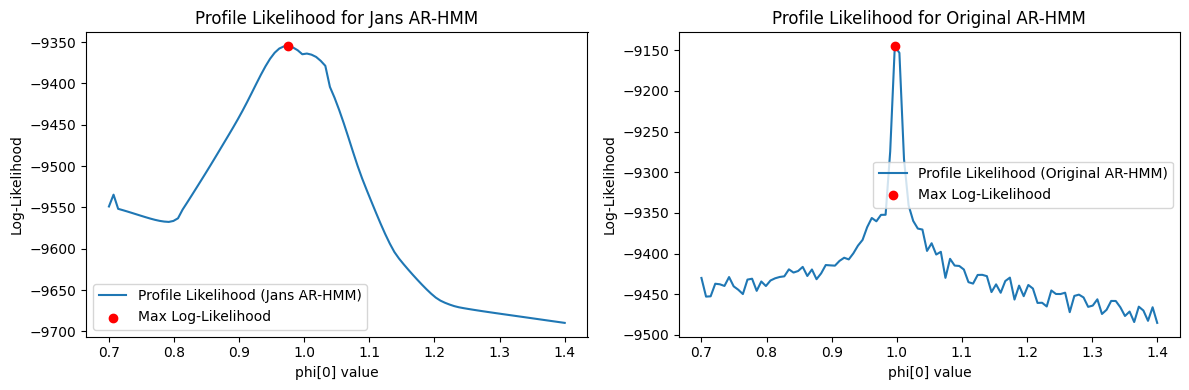

In [17]:
import matplotlib.pyplot as plt

phi_range = (0.7, 1.4)


n_models = len(models_to_plot)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 4))

if n_models == 1:
    axes = [axes]
axes = axes.flatten() 

for i, (model_name, model) in enumerate(models_to_plot.items()):
    phi_space, log_likes = profile_likelihood(
        model=model,  
        y=y, X=X, 
        phi_range=phi_range, 
        loss_generator=make_loss_fixed_phi0, 
        num_points=100
    )

    # Plotting
    ax = axes[i]
    #print max log-likelihood and corresponding phi value in the plot
    max_idx = jnp.argmax(log_likes)
    print(f"{model_name} - Max Log-Likelihood: {log_likes[max_idx]:.4f} at phi[0]={phi_space[max_idx]:.4f}")
    ax.plot(phi_space, log_likes, label=f'Profile Likelihood ({model_name})')
    ax.set_title(f'Profile Likelihood for {model_name}')
    ax.set_xlabel('phi[0] value')
    ax.set_ylabel('Log-Likelihood')
    #Plot point of max log-likelihood and value of phi[0] at that point
    ax.scatter(phi_space[max_idx], log_likes[max_idx], color='red', label='Max Log-Likelihood', zorder=5)
    ax.legend()

plt.tight_layout()
plt.show()


The reason i got a different Phi value was because i conditioned the first y0 value on being equal phi. This of course would jamp up the phi values such that the initial y0 is more close to phi0. 

Look into conditional and non-condition MLE. 

IN PROFILE LIKELIHOOD PICTURE \
Jans AR-HMM - Max Log-Likelihood: -9354.8601 at phi[0]=0.9758 \
Original AR-HMM - Max Log-Likelihood: -9144.8771 at phi[0]=0.9970

In [ ]:
from src.optim.lbfgs import LFBGSOptimizer
from src.data import save_model_and_data
from src.models.v1.ar_hmm import ArHMM

params, _, _ = load_model_and_data(modelname=MODELTYPES.AR_HMM, tag=RUN_TO_LOAD["tag"], run=RUN_TO_LOAD["run"])
model = ArHMM(transition_logits=params.transition_logits, mu=params.mu, log_sigma=jnp.log(params.sigma), phi=params.phi)

optimizer = LFBGSOptimizer(
    model=model,
    loss_fn=negative_log_likelihood
)

opt_model = optimizer.run(y, X)

print(f"Log-Likelihood of AR-HMM model: {-negative_log_likelihood(opt_model, y, X):.4f}")

save_model_and_data(model=opt_model, y=y, X=X, modelname=MODELTYPES.AR_HMM, tag="week_3", run=1)